## Import

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

# Phase 1 

In [135]:
dataset_cancer = load_breast_cancer()

X_cancer = dataset_cancer.data
y_cancer = dataset_cancer.target

noms_classes_cancer = np.array(["maligne", "bénigne"])

print("Dataset chargé.")
print("Forme de X :", X_cancer.shape)
print("Forme de y :", y_cancer.shape)

Dataset chargé.
Forme de X : (569, 30)
Forme de y : (569,)


## Fonction d’exploration

In [136]:
def explorer_dataset(X=None, y=None, noms_classes=None):
    

    
    if X is None or y is None:
        dataset = load_breast_cancer()
        X = dataset.data
        y = dataset.target
        noms_classes = np.array(["maligne", "bénigne"])

    nombre_lignes, nombre_colonnes = X.shape

    print("Lignes, colonnes :", (nombre_lignes, nombre_colonnes))
    print("Nombre total d'observations :", len(y))
    print()

    classes, effectifs = np.unique(y, return_counts=True)

    for classe, effectif in zip(classes, effectifs):
        pourcentage = effectif / len(y) * 100

        if noms_classes is not None and classe < len(noms_classes):
            nom = noms_classes[classe]
        else:
            nom = str(classe)

        print(
            f"Classe {classe} ({nom}) : "
            f"{effectif} cas ({pourcentage:.1f} %)"
        )

In [137]:
explorer_dataset()

Lignes, colonnes : (569, 30)
Nombre total d'observations : 569

Classe 0 (maligne) : 212 cas (37.3 %)
Classe 1 (bénigne) : 357 cas (62.7 %)


### Cas normal 

In [138]:
print("TEST 1 — Dataset ")
print("-" * 40)

explorer_dataset(
    X_cancer,
    y_cancer,
    noms_classes_cancer
)


TEST 1 — Dataset 
----------------------------------------
Lignes, colonnes : (569, 30)
Nombre total d'observations : 569

Classe 0 (maligne) : 212 cas (37.3 %)
Classe 1 (bénigne) : 357 cas (62.7 %)


### Cas limite avec une seule classe 

In [139]:
masque_malignes = y_cancer == 0

X_malignes = X_cancer[masque_malignes]
y_malignes = y_cancer[masque_malignes]

print("TEST 2 — Datasetavec Une seule classe")
print("-" * 40)

explorer_dataset(
    X_malignes,
    y_malignes,
    noms_classes_cancer
)

TEST 2 — Datasetavec Une seule classe
----------------------------------------
Lignes, colonnes : (212, 30)
Nombre total d'observations : 212

Classe 0 (maligne) : 212 cas (100.0 %)


### Cas avec 95% d'une classe 

In [140]:
X_adversarial = X_cancer[:100]

y_adversarial = np.array(
    [0] * 95 +
    [1] * 5
)

print("TEST 3 — Dataset déséquilibré")
print("-" * 40)

explorer_dataset(
    X_adversarial,
    y_adversarial,
    noms_classes_cancer
)

TEST 3 — Dataset déséquilibré
----------------------------------------
Lignes, colonnes : (100, 30)
Nombre total d'observations : 100

Classe 0 (maligne) : 95 cas (95.0 %)
Classe 1 (bénigne) : 5 cas (5.0 %)


# Phase 2 

### Configurer mon Github 

In [141]:
!git config --global user.name "HOUDA OUADAH"

In [142]:
!git config --global user.email "houdaouadah61@gmail.com"

In [143]:
!git config --global --list

user.name=HOUDA OUADAH
user.email=houdaouadah61@gmail.com
filter.lfs.smudge=git-lfs smudge -- %f
filter.lfs.process=git-lfs filter-process
filter.lfs.required=true
filter.lfs.clean=git-lfs clean -- %f
credential.helperselector.selected=manager


In [144]:
from pathlib import Path

print(Path.cwd())

C:\Users\houda\Documents\arene-des-algos-HOUDAOUADAH


In [145]:
!git rev-parse --show-toplevel

C:/Users/houda/Documents/arene-des-algos-HOUDAOUADAH


In [146]:
from pathlib import Path

dossier_projet = (
    Path.home()
    / "Documents"
    / "arene-des-algos-HOUDAOUADAH"
)

print("Le dossier existe :", dossier_projet.exists())

if dossier_projet.exists():
    print("Contenu :", list(dossier_projet.iterdir()))

Le dossier existe : True
Contenu : [WindowsPath('C:/Users/houda/Documents/arene-des-algos-HOUDAOUADAH/.git'), WindowsPath('C:/Users/houda/Documents/arene-des-algos-HOUDAOUADAH/.gitignore'), WindowsPath('C:/Users/houda/Documents/arene-des-algos-HOUDAOUADAH/.ipynb_checkpoints'), WindowsPath('C:/Users/houda/Documents/arene-des-algos-HOUDAOUADAH/arene_des_algos_HOUDAOUADAH.ipynb'), WindowsPath('C:/Users/houda/Documents/arene-des-algos-HOUDAOUADAH/README.md')]


In [147]:
from pathlib import Path
import subprocess

url_github = "https://github.com/houdaouadah61/-arene-des-algos-HOUDAOUADAH.git"

dossier_projet = (
    Path.home()
    / "Documents"
    / "arene-des-algos-HOUDAOUADAH"
)

resultat = subprocess.run(
    [
        "git",
        "clone",
        url_github,
        str(dossier_projet),
    ],
    text=True,
    capture_output=True,
)

print(resultat.stdout)
print(resultat.stderr)
print("Code de retour :", resultat.returncode)


fatal: destination path 'C:\Users\houda\Documents\arene-des-algos-HOUDAOUADAH' already exists and is not an empty directory.

Code de retour : 128


In [148]:
print("Dossier créé :", dossier_projet.exists())

if dossier_projet.exists():
    for fichier in dossier_projet.iterdir():
        print(fichier.name)

Dossier créé : True
.git
.gitignore
.ipynb_checkpoints
arene_des_algos_HOUDAOUADAH.ipynb
README.md


In [149]:
from pathlib import Path

print(Path.cwd())

C:\Users\houda\Documents\arene-des-algos-HOUDAOUADAH


In [150]:
from pathlib import Path

contenu_gitignore = """# Fichiers temporaires Jupyter
.ipynb_checkpoints/

# Fichiers temporaires Python
__pycache__/
*.pyc
"""

Path(".gitignore").write_text(
    contenu_gitignore,
    encoding="utf-8"
)

print(".gitignore créé")

.gitignore créé


In [151]:
import os

print(os.listdir())

['.git', '.gitignore', '.ipynb_checkpoints', 'arene_des_algos_HOUDAOUADAH.ipynb', 'README.md']


In [152]:
from pathlib import Path

print(Path(".gitignore").read_text(encoding="utf-8"))

# Fichiers temporaires Jupyter
.ipynb_checkpoints/

# Fichiers temporaires Python
__pycache__/
*.pyc



In [153]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   arene_des_algos_HOUDAOUADAH.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


In [154]:
!git log --oneline --max-count=5

59b4ce4 docs(readme): presente le classement et justifie le champion
5d5a3b5 feat(scaling): compare le scaling et la fuite de donnees
0c47eb7 feat(visualisation): ajoute le graphique et la matrice de confusion
bc3e551 feat(dataset): ajoute le classement sur wine
b0ca25f feat(dataset): ajoute le classement sur wine


In [155]:
!git status --short

 M arene_des_algos_HOUDAOUADAH.ipynb


In [156]:
!git add .gitignore

In [157]:
!git add arene_des_algos_HOUDAOUADAH.ipynb

In [158]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   arene_des_algos_HOUDAOUADAH.ipynb



In [159]:
!git push origin main

To https://github.com/houdaouadah61/-arene-des-algos-HOUDAOUADAH.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/houdaouadah61/-arene-des-algos-HOUDAOUADAH.git'
hint: Updates were rejected because the remote contains work that you do not
hint: have locally. This is usually caused by another repository pushing to
hint: the same ref. If you want to integrate the remote changes, use
hint: 'git pull' before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [160]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   arene_des_algos_HOUDAOUADAH.ipynb



In [161]:
!git commit -m "chore(setup): ajoute le notebook et le gitignore"

[main a4a7010] chore(setup): ajoute le notebook et le gitignore
 1 file changed, 10 insertions(+), 2 deletions(-)


# Phase 2: Suite du TP 

In [162]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [163]:
# Je recharge le dataset pour être sûr que X et y existent

dataset = load_breast_cancer()

X = dataset.data
y = dataset.target

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (569, 30)
Dimensions de y : (569,)


2.1 Séparer les données 

In [164]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Taille de X_train :", X_train.shape)
print("Taille de X_test :", X_test.shape)
print("Taille de y_train :", y_train.shape)
print("Taille de y_test :", y_test.shape)

Taille de X_train : (455, 30)
Taille de X_test : (114, 30)
Taille de y_train : (455,)
Taille de y_test : (114,)


2.2 créer la fonction 

In [165]:
def entrainer_et_evaluer(
    modele,
    X_train,
    X_test,
    y_train,
    y_test
):
    

    # Entraînement du modèle
    modele.fit(X_train, y_train)

    # Prédiction sur les données de test
    y_pred = modele.predict(X_test)

    
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy

2.3 tester la fonction avec un arbre de décision 

In [166]:
# Création du modèle

arbre = DecisionTreeClassifier(
    random_state=42
)

# Entraînement et évaluation

score_arbre = entrainer_et_evaluer(
    arbre,
    X_train,
    X_test,
    y_train,
    y_test
)

print("Accuracy obtenue :", score_arbre)
print("Accuracy en pourcentage :", f"{score_arbre:.2%}")

Accuracy obtenue : 0.9122807017543859
Accuracy en pourcentage : 91.23%


In [167]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 2 commits.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [168]:
!git add arene_des_algos_HOUDAOUADAH.ipynb

In [169]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 2 commits.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [170]:
!git commit -m "feat(pipeline): ajoute le pipeline supervise breast cancer" 

On branch main
Your branch is ahead of 'origin/main' by 2 commits.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [171]:
!git push origin main

To https://github.com/houdaouadah61/-arene-des-algos-HOUDAOUADAH.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/houdaouadah61/-arene-des-algos-HOUDAOUADAH.git'
hint: Updates were rejected because the remote contains work that you do not
hint: have locally. This is usually caused by another repository pushing to
hint: the same ref. If you want to integrate the remote changes, use
hint: 'git pull' before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [172]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 2 commits.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [173]:
!git add arene_des_algos_HOUDAOUADAH.ipynb

In [174]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 2 commits.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [175]:
!git commit -m "feat(pipeline): ajoute le pipeline supervise breast cancer"

On branch main
Your branch is ahead of 'origin/main' by 2 commits.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [176]:
!git push origin main

To https://github.com/houdaouadah61/-arene-des-algos-HOUDAOUADAH.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/houdaouadah61/-arene-des-algos-HOUDAOUADAH.git'
hint: Updates were rejected because the remote contains work that you do not
hint: have locally. This is usually caused by another repository pushing to
hint: the same ref. If you want to integrate the remote changes, use
hint: 'git pull' before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [177]:
!git log --oneline --max-count=3

a4a7010 chore(setup): ajoute le notebook et le gitignore
59b4ce4 docs(readme): presente le classement et justifie le champion
5d5a3b5 feat(scaling): compare le scaling et la fuite de donnees


# Phase 3 

In [178]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

3.1 Tester la regression logistique 

In [179]:
regression_test = LogisticRegression(
    max_iter=100,
    random_state=42
)

score_regression_test = entrainer_et_evaluer(
    regression_test,
    X_train,
    X_test,
    y_train,
    y_test
)

print(
    "Accuracy de la régression logistique :",
    f"{score_regression_test:.2%}"
)

Accuracy de la régression logistique : 95.61%


C:\Users\houda\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


3.2 créer la fonction Arene

In [180]:
def arene(
    X_train,
    X_test,
    y_train,
    y_test
):
    

   
    modeles = {
        "Régression logistique": LogisticRegression(
            max_iter=5000,
            random_state=42
        ),

        "KNN": KNeighborsClassifier(
            n_neighbors=5
        ),

        "Arbre de décision": DecisionTreeClassifier(
            random_state=42
        )
    }

    resultats = []

    
    for nom, modele in modeles.items():

        score = entrainer_et_evaluer(
            modele,
            X_train,
            X_test,
            y_train,
            y_test
        )

        resultats.append(
            {
                "Algorithme": nom,
                "Accuracy": score
            }
        )

    
    resultats = sorted(
        resultats,
        key=lambda resultat: resultat["Accuracy"],
        reverse=True
    )

    print("Classement de l'Arène")
    print("-" * 45)

    for rang, resultat in enumerate(
        resultats,
        start=1
    ):
        print(
            f"{rang}. {resultat['Algorithme']} : "
            f"{resultat['Accuracy']:.2%}"
        )

    return resultats
    

In [181]:
classement_cancer = arene(
    X_train,
    X_test,
    y_train,
    y_test
)

Classement de l'Arène
---------------------------------------------
1. Régression logistique : 96.49%
2. KNN : 91.23%
3. Arbre de décision : 91.23%


# Phase 4 

In [182]:
from sklearn.cluster import KMeans

4.1 Créer la fonction

In [183]:
def clustering_aveugle(X):
    

    kmeans = KMeans(
        n_clusters=2,
        random_state=42,
        n_init=10
    )

    clusters = kmeans.fit_predict(X)

    return clusters

In [184]:
clusters_cancer = clustering_aveugle(X)

print("Nombre de clusters trouvés :", len(set(clusters_cancer)))
print("Premiers résultats :", clusters_cancer[:20])

Nombre de clusters trouvés : 2
Premiers résultats : [0 0 0 1 0 1 0 1 1 1 1 0 0 1 1 1 1 0 0 1]


C:\Users\houda\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


4.2 comparer avec des vraies classes 

In [185]:
import pandas as pd
comparaison_clusters = pd.crosstab(
    y,
    clusters_cancer,
    rownames=["Vraie classe"],
    colnames=["Cluster trouvé"]
)

comparaison_clusters

Cluster trouvé,0,1
Vraie classe,,
0,130,82
1,1,356


 - Classe 0 : tumeur maligne
 - Classe 1 : tumeur bénigne

# Phase 5 : 

In [186]:
from sklearn.datasets import load_wine

dataset_wine = load_wine()

X_wine = dataset_wine.data
y_wine = dataset_wine.target
noms_classes_wine = dataset_wine.target_names
explorer_dataset(
    X_wine,
    y_wine,
    noms_classes_wine
)

Lignes, colonnes : (178, 13)
Nombre total d'observations : 178

Classe 0 (class_0) : 59 cas (33.1 %)
Classe 1 (class_1) : 71 cas (39.9 %)
Classe 2 (class_2) : 48 cas (27.0 %)


5.1 Séparer les données 

In [187]:
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine,
    y_wine,
    test_size=0.20,
    random_state=42,
    stratify=y_wine
)

print("X_train_wine :", X_train_wine.shape)
print("X_test_wine :", X_test_wine.shape)
classement_wine = arene(
    X_train_wine,
    X_test_wine,
    y_train_wine,
    y_test_wine
)

X_train_wine : (142, 13)
X_test_wine : (36, 13)
Classement de l'Arène
---------------------------------------------
1. Régression logistique : 94.44%
2. Arbre de décision : 94.44%
3. KNN : 80.56%


C:\Users\houda\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Phase 6 

In [188]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

6.1 préparer les données du graphique

In [189]:
noms_algorithmes = []
accuracies = []

for resultat in classement_cancer:
    noms_algorithmes.append(
        resultat["Algorithme"]
    )

    accuracies.append(
        resultat["Accuracy"]
    )

print(noms_algorithmes)
print(accuracies)

['Régression logistique', 'KNN', 'Arbre de décision']
[0.9649122807017544, 0.9122807017543859, 0.9122807017543859]


6.2 diagramme en barre

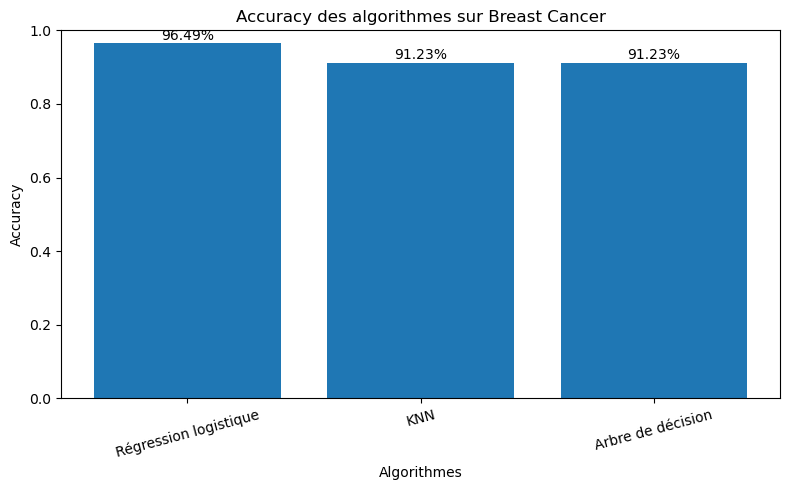

In [190]:
plt.figure(figsize=(8, 5))

plt.bar(
    noms_algorithmes,
    accuracies
)

plt.title(
    "Accuracy des algorithmes sur Breast Cancer"
)

plt.xlabel("Algorithmes")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.xticks(
    rotation=15
)

for position, score in enumerate(accuracies):
    plt.text(
        position,
        score + 0.01,
        f"{score:.2%}",
        ha="center"
    )

plt.tight_layout()
plt.show()

6.3 identifier le champion 

In [191]:
nom_champion = classement_cancer[0]["Algorithme"]

accuracy_champion = classement_cancer[0]["Accuracy"]

print("Champion :", nom_champion)
print(
    "Accuracy du champion :",
    f"{accuracy_champion:.2%}"
)

Champion : Régression logistique
Accuracy du champion : 96.49%


6.4 Recréer les modèles

In [192]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

modeles = {
    "Régression logistique": LogisticRegression(
        max_iter=5000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Arbre de décision": DecisionTreeClassifier(
        random_state=42
    )
}

In [193]:
champion = modeles[nom_champion]

champion.fit(
    X_train,
    y_train
)

predictions_champion = champion.predict(
    X_test
)

print(
    "Nombre de prédictions :",
    len(predictions_champion)
)

Nombre de prédictions : 114


6.5 calcul de la matrice de confusion 

In [194]:
matrice_confusion = confusion_matrix(
    y_test,
    predictions_champion
)

print("Matrice de confusion :")
print(matrice_confusion)

Matrice de confusion :
[[39  3]
 [ 1 71]]


6.6 Tracer la matrice de confusion 

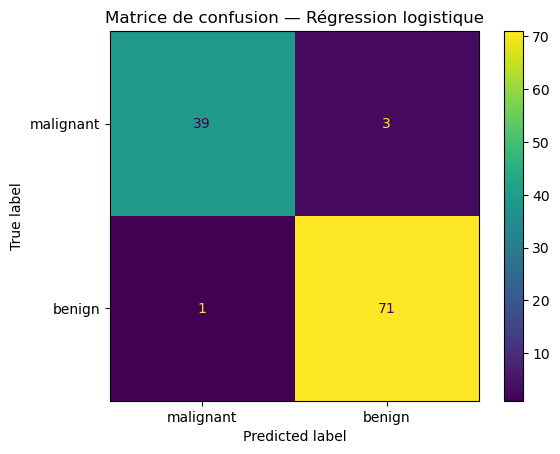

In [195]:
affichage = ConfusionMatrixDisplay(
    confusion_matrix=matrice_confusion,
    display_labels=noms_classes
)

affichage.plot()

plt.title(
    f"Matrice de confusion — {nom_champion}"
)

plt.show()

# Phase 7 

7.1 Préparer les modèles

In [196]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
modeles_scaling = {
    "Régression logistique": LogisticRegression(
        max_iter=5000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Arbre de décision": DecisionTreeClassifier(
        random_state=42
    )
}

7.2 Créer la fonction comparer_scaling

In [197]:
def comparer_scaling(
    modeles,
    X_train,
    X_test,
    y_train,
    y_test
):

    resultats = []

    # Mise à l'échelle des données
    scaler = StandardScaler()

    X_train_scale = scaler.fit_transform(
        X_train
    )

    X_test_scale = scaler.transform(
        X_test
    )

    for nom, modele in modeles.items():

        # Accuracy sans scaling
        score_brut = entrainer_et_evaluer(
            modele,
            X_train,
            X_test,
            y_train,
            y_test
        )

        # Accuracy avec scaling
        score_scale = entrainer_et_evaluer(
            modele,
            X_train_scale,
            X_test_scale,
            y_train,
            y_test
        )

        gain = score_scale - score_brut

        resultats.append(
            {
                "Algorithme": nom,
                "Brut": score_brut,
                "Scalé": score_scale,
                "Gain": gain
            }
        )

    # Création du tableau
    tableau = pd.DataFrame(resultats)

    # Classement par gain décroissant
    tableau = tableau.sort_values(
        by="Gain",
        ascending=False
    )

    return tableau

In [198]:
comparaison_scaling = comparer_scaling(
    modeles_scaling,
    X_train,
    X_test,
    y_train,
    y_test
)

comparaison_scaling

,Algorithme,Brut,Scalé,Gain
1,KNN,0.912281,0.956140,0.043860
0,Régression logistique,0.964912,0.982456,0.017544
2,Arbre de décision,0.912281,0.912281,0.000000


7.2.1 Afficher les résultats en pourcentage 

In [199]:
for _, ligne in comparaison_scaling.iterrows():

    print(
        ligne["Algorithme"],
        "| Brut :",
        f"{ligne['Brut']:.2%}",
        "| Scalé :",
        f"{ligne['Scalé']:.2%}",
        "| Gain :",
        f"{ligne['Gain']:+.2%}"
    )

KNN | Brut : 91.23% | Scalé : 95.61% | Gain : +4.39%
Régression logistique | Brut : 96.49% | Scalé : 98.25% | Gain : +1.75%
Arbre de décision | Brut : 91.23% | Scalé : 91.23% | Gain : +0.00%


7.3 Créer volontairement une fuite de données

7.3.1 Trouver le champion après scaling

In [200]:
index_champion = comparaison_scaling["Scalé"].idxmax()

nom_champion_scale = comparaison_scaling.loc[
    index_champion,
    "Algorithme"
]

print(
    "Champion après scaling :",
    nom_champion_scale
)

Champion après scaling : Régression logistique


7.3.2 Le scaler est ajusté uniquement sur les données d’entraînement

In [201]:
scaler_honnete = StandardScaler()

X_train_honnete = scaler_honnete.fit_transform(
    X_train
)

X_test_honnete = scaler_honnete.transform(
    X_test
)

champion_honnete = modeles_scaling[
    nom_champion_scale
]

score_honnete = entrainer_et_evaluer(
    champion_honnete,
    X_train_honnete,
    X_test_honnete,
    y_train,
    y_test
)

print(
    "Accuracy honnête :",
    f"{score_honnete:.2%}"
)

Accuracy honnête : 98.25%


7.3.3 Version avec fuite de données

In [202]:
scaler_triche = StandardScaler()


X_scale_triche = scaler_triche.fit_transform(X)

(
    X_train_triche,
    X_test_triche,
    y_train_triche,
    y_test_triche
) = train_test_split(
    X_scale_triche,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

champion_triche = modeles_scaling[
    nom_champion_scale
]

score_triche = entrainer_et_evaluer(
    champion_triche,
    X_train_triche,
    X_test_triche,
    y_train_triche,
    y_test_triche
)

print(
    "Accuracy avec fuite :",
    f"{score_triche:.2%}"
)

Accuracy avec fuite : 98.25%


In [203]:
difference = score_triche - score_honnete

print(
    "Différence entre la version truquée et la version honnête :",
    f"{difference:+.2%}"
)

Différence entre la version truquée et la version honnête : +0.00%


### Interpretation 

La version honnête obtient une accuracy de 98,2456 %.

La version avec fuite de données obtient exactement la même accuracy,
soit 98,2456 %. La différence est donc de 0 %.

Dans ce cas précis, la fuite de données n'a pas amélioré le résultat
Cependant, la méthode avec fuite reste incorrecte. En effet, le scaler
a utilisé les données de test pour calculer la moyenne et l'écart-type.
Le jeu de test a donc influencé la préparation des données alors qu'il
devrait rester totalement inconnu jusqu'à l'évaluation finale.

# Phase 8 

8.1 Vérification des résultats 

In [204]:
print("Classement Breast Cancer")
print("-" * 40)

for rang, resultat in enumerate(classement_cancer, start=1):
    print(
        f"{rang}. {resultat['Algorithme']} : "
        f"{resultat['Accuracy']:.2%}"
    )

Classement Breast Cancer
----------------------------------------
1. Régression logistique : 96.49%
2. KNN : 91.23%
3. Arbre de décision : 91.23%


8.2 Classement Wine 

In [205]:
print("Classement Wine")
print("-" * 40)

for rang, resultat in enumerate(classement_wine, start=1):
    print(
        f"{rang}. {resultat['Algorithme']} : "
        f"{resultat['Accuracy']:.2%}"
    )

Classement Wine
----------------------------------------
1. Régression logistique : 94.44%
2. Arbre de décision : 94.44%
3. KNN : 80.56%
